<a href="https://colab.research.google.com/github/musowjanya/DL_Mini_Projects/blob/main/Convolution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [325]:
import numpy as np
import matplotlib.pyplot as plt

In [326]:
ar=np.array([3,5,6,2,1,5])

In [327]:
np.convolve(ar,[1,2,3]) #(3,2,1)

array([ 3, 11, 25, 29, 23, 13, 13, 15])

Convolution on the Images from Load_digits

In [328]:
from sklearn.datasets import load_digits

In [329]:
dt = load_digits(n_class=3)

In [330]:
dt.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [331]:
dt.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [332]:
# dt.target

In [333]:
dt.images.shape

(537, 8, 8)

In [334]:
X = dt.images
Y = dt.target

In [335]:
X = X.reshape(537,1,8,8)

In [336]:
import torch
import torch.nn as nn
from torch.optim import Adam

In [337]:
X = torch.FloatTensor(X)
Y = torch.LongTensor(Y)

In [338]:
X.shape

torch.Size([537, 1, 8, 8])

In [339]:
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(64*2*2, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
)

In [340]:
loss = nn.CrossEntropyLoss()
opt = Adam(model.parameters(), lr=0.001)

In [341]:
c=0
for epoch in range(100):
    c=c+1
    opt.zero_grad()
    yp = model(X)
    ls = loss(yp, Y)
    ls.backward()
    opt.step()
    if c%10==0:
      print(ls.item())

0.16469161212444305
0.021425453945994377
0.004592861980199814
0.001891692285425961
0.0009344387799501419
0.0006308085867203772
0.0004698085249401629
0.0003655866894405335
0.00028990188729949296
0.00023333670105785131


Prediction on new data

In [342]:
newx = X[112].reshape(1,1,8,8)

In [343]:
newx.shape

torch.Size([1, 1, 8, 8])

In [344]:
Yp = model(newx)

In [345]:
Yp

tensor([[-3.6376,  6.8519, -3.5603]], grad_fn=<AddmmBackward0>)

In [346]:
sx=torch.softmax(Yp, dim=1)

In [347]:
torch.argmax(sx, dim=1)

tensor([1])

In [348]:
# import matplotlib.pyplot as plt
# plt.imshow(Yp, cmap='gray')
# plt.show()

Inference  (Using Batches)

In [349]:
from torch.utils.data import TensorDataset, DataLoader
dataset = TensorDataset(X, Y)

In [350]:
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [351]:
lossfn = nn.CrossEntropyLoss()

In [368]:
model.train()
# for _ in range(100):
#     opt.zero_grad()
#     Yp = model(X)
#     loss = lossfn(Yp, Y)
#     loss.backward()
#     opt.step()
#     print(loss)
dataset = TensorDataset(X, Y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

for epoch in range(200):
    for xb, yb in loader:
        opt.zero_grad()
        Yp = model(xb)
        loss = lossfn(Yp, yb)
        loss.backward()
        opt.step()

In [353]:
model(X)

tensor([[ 13.9434, -10.4245, -12.4790],
        [ -8.0754,  15.9592, -12.7048],
        [ -7.1091,  -2.9411,  11.4071],
        ...,
        [-10.6033,  -4.8246,  17.2939],
        [ -8.7763,  -4.6955,  14.9885],
        [ 14.8266, -11.1372, -13.8600]], grad_fn=<AddmmBackward0>)

In [354]:
import cv2

In [357]:
ar=cv2.imread('/content/zero new.png')

In [358]:
ar.shape

(348, 348, 3)

In [359]:
grar=cv2.cvtColor(ar,cv2.COLOR_BGR2GRAY)

In [360]:
rszar=cv2.resize(grar,(8,8))

In [361]:
far=rszar.reshape(1,1,8,8)

In [362]:
far

array([[[[255, 238, 255, 238, 255, 255, 238, 255],
         [238, 255, 145, 145, 145, 147, 255, 238],
         [255, 238, 189, 238, 211, 185, 238, 255],
         [238, 193, 218, 255, 238, 218, 255, 238],
         [255, 152, 213, 238, 255, 212, 238, 255],
         [255, 238, 177, 238, 255, 180, 238, 255],
         [238, 255, 139, 143, 139, 234, 255, 238],
         [255, 238, 255, 238, 255, 255, 238, 255]]]], dtype=uint8)

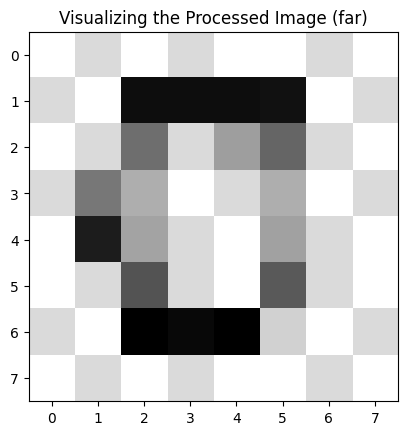

In [363]:
plt.imshow(far.squeeze(), cmap='gray')
plt.title('Visualizing the Processed Image (far)')
plt.show()

In [364]:
fimg = torch.from_numpy(far).float()
print(f"Shape of fimg before model call: {fimg.shape}")

Shape of fimg before model call: torch.Size([1, 1, 8, 8])


In [365]:
model(fimg)

tensor([[  1.5197, -26.6659, -31.5125]], grad_fn=<AddmmBackward0>)

In [366]:
sfx=torch.softmax(model(fimg),dim=1)

In [367]:
torch.argmax(sfx,dim=1)

tensor([0])